In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from statistics import mean
import joblib

In [2]:
# Remove unnecessary columns
def clean_csv(old_filename, new_filename, remove_col_list):
    try:
        df = pd.read_csv(old_filename)
        df.drop(columns=remove_col_list, inplace=True)

        # for i, row in enumerate(df):
        #     df.iloc[i, 1] = len(df["URL"].iloc[i])

        df.to_csv(new_filename, index=False)

        print(f'file: "{old_filename}" cleaned successfully')
        return True
    except Exception as e:
        print(f'file: "{old_filename}" clean failed ({e})')
        return False

In [3]:
# Loads features and target variables
def load_data(filename, y_target_name, num_rows=-1, pos=0):
    df = pd.read_csv(filename)
    if num_rows > 0:
        df = df[pos : pos + num_rows]
    elif pos != 0:
        df = df[pos:]

    X = df.drop(columns=[y_target_name])
    y = df[y_target_name]

    return X, y, df

In [4]:
def show_corr_matrix(df, output_filename):
    non_valid_cols = [
        df.columns[i]
        for i, item in enumerate(df.dtypes)
        if not pd.api.types.is_numeric_dtype(item)
    ]
    df.drop(columns=non_valid_cols, inplace=True)
    matrix = df.corr()
    plt.figure(figsize=(32, 16))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("UCI Phishing URL Correlation Heatmap")
    plt.savefig(output_filename)

In [5]:
def get_training_test_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
    return X_train, X_test, y_train, y_test

In [6]:
def logistic_regression_model_training(X_train, X_test, y_train, y_test):
    C_grid = np.logspace(-4, 4, 20)
    y_train_log_loss_data = []
    y_test_log_loss_data = []
    for i, C in enumerate(C_grid):
        print(f"working on {i} with C value: {C:.4f}")
        clf = LogisticRegression(C=C, l1_ratio=0, solver="lbfgs", max_iter=500).fit(
            X_train, y_train
        )
        y_train_pred = clf.predict_proba(X_train)
        y_test_pred = clf.predict_proba(X_test)
        y_train_log_loss = log_loss(y_train, y_train_pred)
        y_test_log_loss = log_loss(y_test, y_test_pred)

        # print(f"{y_train_pred=}")
        # print(f"{y_test_pred=}")
        print(f"{y_train_log_loss=:.4f}")
        print(f"{y_test_log_loss=:.4f}")
        y_train_log_loss_data.append(y_train_log_loss)
        y_test_log_loss_data.append(y_test_log_loss)

    plt.figure()
    plt.plot(
        C_grid,
        y_train_log_loss_data,
        "o-",
        color="blue",
        label="Training Data Log-Loss",
        markersize=3,
    )
    plt.plot(
        C_grid,
        y_test_log_loss_data,
        "o-",
        color="red",
        label="Test Data Log-Loss",
        markersize=3,
    )

    plt.xlabel("C")
    plt.ylabel("Log-Loss")
    plt.title("Log-Loss of Training and Test Data Vs C")
    # plt.ylim([0, 1])
    plt.xscale("log")
    plt.legend()
    plt.savefig("../outputs/logistic_regression_log_loss_c.png")

    clf = LogisticRegression(C=5, l1_ratio=0, solver="lbfgs", max_iter=500).fit(
        X_train, y_train
    )
    return clf

In [16]:
clean_csv(
    "../data/uci_phishing_url_dataset.csv",
    "../data/uci_phishing_url_dataset_clean.csv",
    [
        "URL",
        "Domain",
        "TLD",
        "Title",
        "DomainTitleMatchScore",
        "IsResponsive",
        "HasDescription",
        "NoOfPopup",
        "NoOfiFrame",
        "HasExternalFormSubmit",
        "HasSocialNet",
        "HasSubmitButton",
        "HasHiddenFields",
        "HasPasswordField",
        "Bank",
        "Pay",
        "Crypto",
        "HasCopyrightInfo",
        "NoOfImage",
        "NoOfCSS",
        "URLSimilarityIndex",
        "TLDLegitimateProb",
        "URLCharProb",
        "NoOfURLRedirect",
        "NoOfSelfRedirect"
    ],
)

file: "../data/uci_phishing_url_dataset.csv" cleaned successfully


True

remove "FILENAME" column from data


In [17]:
X, y, df = load_data("../data/uci_phishing_url_dataset_clean.csv", "IsLegit", 100000)

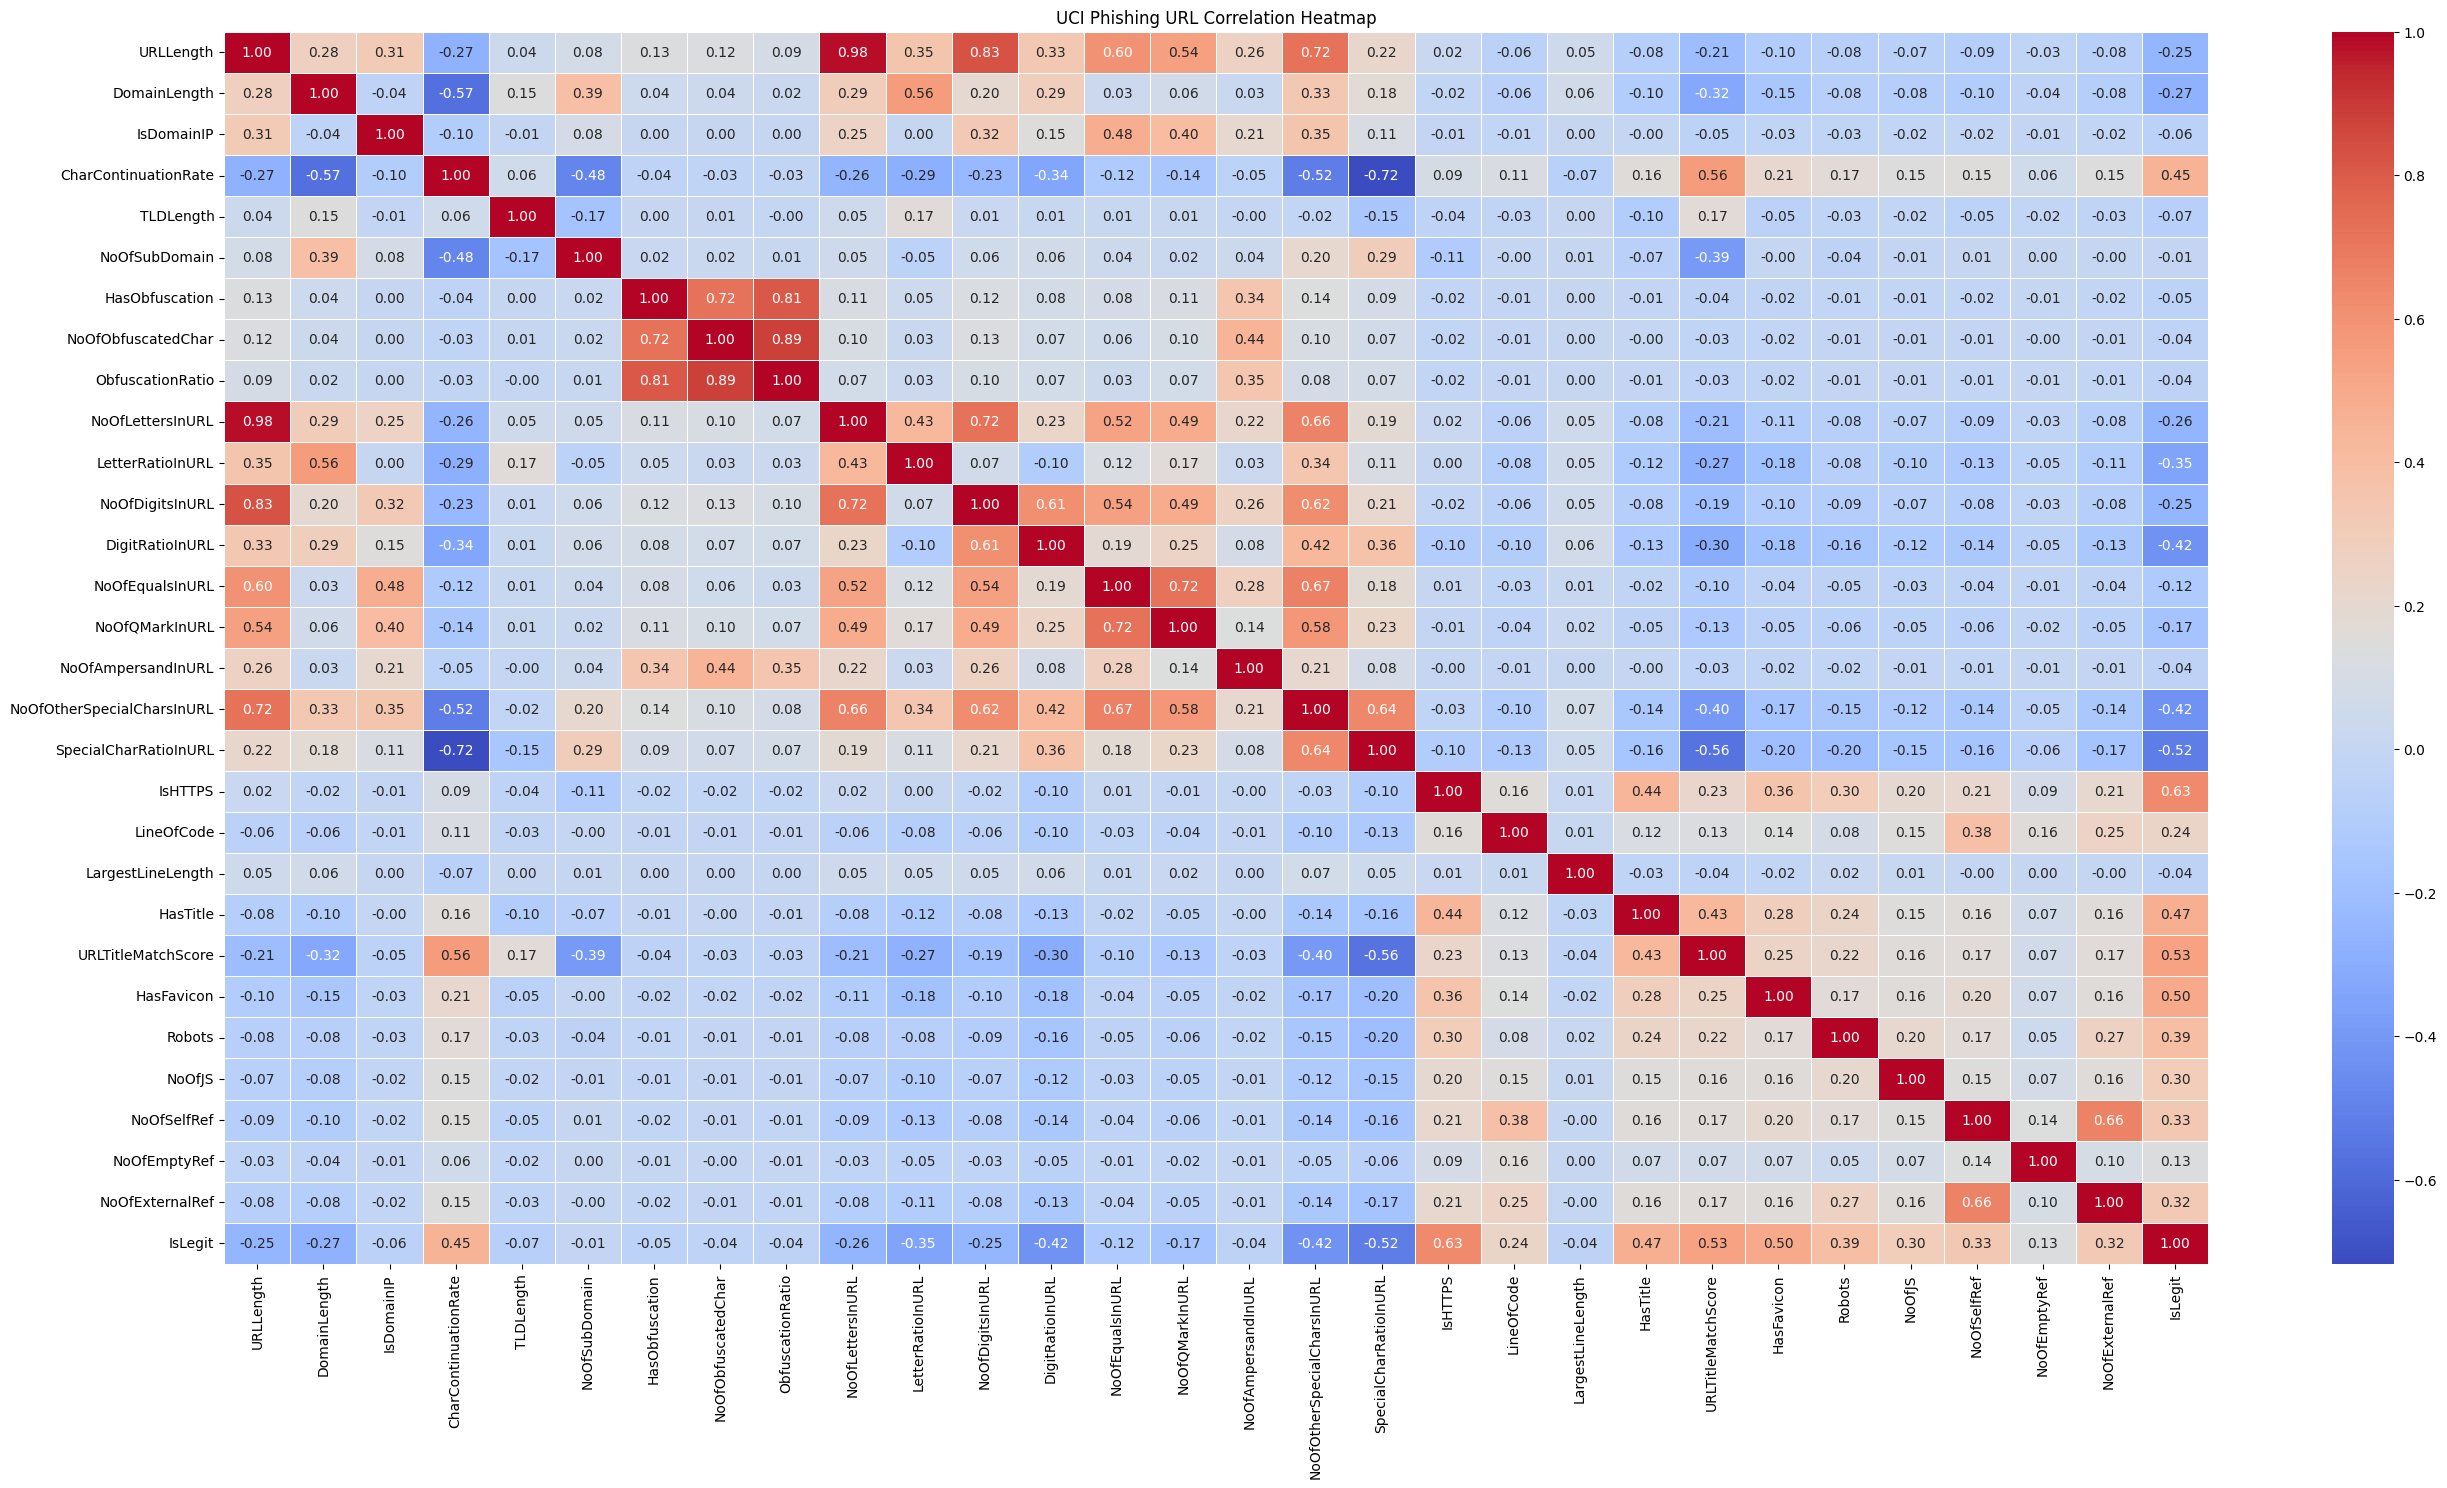

In [18]:
show_corr_matrix(df, "../outputs/uci_phishing_url_corr_matrix.png")

working on 0 with C value: 0.0001
y_train_log_loss=0.0167
y_test_log_loss=0.0193
working on 1 with C value: 0.0003


/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.0141
y_test_log_loss=0.0158
working on 2 with C value: 0.0007


/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.0126
y_test_log_loss=0.0138
working on 3 with C value: 0.0018


...

/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.0019
y_test_log_loss=0.0030
working on 19 with C value: 10000.0000


/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.0019
y_test_log_loss=0.0027


/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


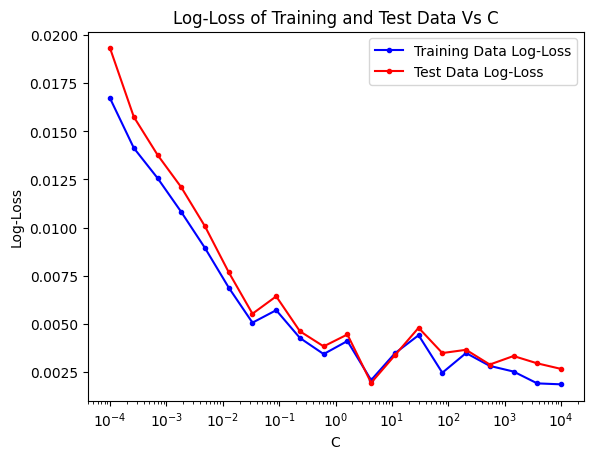

In [19]:
X_train, X_test, y_train, y_test = get_training_test_data(X, y)
clf = logistic_regression_model_training(X_train, X_test, y_train, y_test)

In [20]:
joblib.dump(
    {"features": X_train.columns.tolist(), "model": clf}, "../models/logit_model.pkl"
)

['../models/logit_model.pkl']

In [21]:
X_train

,URLLength,DomainLength,IsDomainIP,CharContinuationRate,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,...,LineOfCode,LargestLineLength,HasTitle,URLTitleMatchScore,HasFavicon,Robots,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
2606,27,20,0,0.846154,2,2,0,0,0.0,13,...,563,2936,1,0.0,0,0,12,51,0,17
57228,21,14,0,0.571429,2,2,0,0,0.0,7,...,320,1820,1,0.0,0,1,5,22,1,27
8382,22,15,0,0.625000,2,2,0,0,0.0,8,...,1305,344,1,0.0,0,0,10,140,6,13
60281,20,13,0,1.000000,3,1,0,0,0.0,7,...,892,14236,1,100.0,1,0,11,35,10,28
48432,29,22,0,1.000000,3,1,0,0,0.0,16,...,619,295,1,0.0,1,0,6,39,0,143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21243,26,20,0,0.545455,4,2,0,0,0.0,13,...,8,41,1,0.0,0,0,0,0,0,0
45891,27,20,0,0.583333,3,1,0,0,0.0,13,...,422,279,1,100.0,1,0,72,69,1,3
42613,27,19,0,0.666667,3,0,0,0,0.0,17,...,15,155,1,100.0,0,0,0,0,0,0
43567,29,22,0,0.533333,2,1,0,0,0.0,15,...,11316,2065,1,0.0,1,0,18,141,7,156


In [22]:
model_dump = joblib.load("../models/logit_model.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_new, df_new = load_data(
    "../data/uci_phishing_url_dataset_clean.csv", "IsLegit", pos=100000
)
print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])

accuracy = accuracy_score(y_new, y_new_pred)
print(f"Accuracy: {accuracy}")

[[-3.23778114e+00  7.01739775e+00 -7.31048815e-03  1.00059803e-01
  -9.10727584e-01  7.79067207e-01  1.30099585e-03  2.48152459e-02
   1.38934234e-04 -4.16004139e+00 -3.83713588e-02 -6.52304307e+00
  -1.84245144e-01 -8.45311621e-02 -3.65948198e-02 -2.29262437e-02
  -4.26184745e+00 -1.54502296e-01  6.29510857e+00  3.16854575e-02
  -1.07869432e-03  6.88608379e-02  4.33826491e-03  1.22575168e+00
   2.75427577e-01  5.37957387e-01  2.06487002e-01 -2.03856936e-01
   1.29724459e-01]]
Accuracy: 0.9986302883022202
